Conectando a la NOAA para descargar el producto Snow/Fog RGB (2026-08-19 13:00:00 UTC)...
Cargando desde disco...
Calibrando componentes físicos del producto Snow/Fog RGB...
Carimbo y logos adaptados correctamente.
¡Producto Snow/Fog RGB generado con éxito!: /Users/diegoperales/Meteorology/GOES/procesados/GOES19_DaySnowFog_SENAMHI_DEPARTAMENTO_BOLIVIA_20260819_1305.png


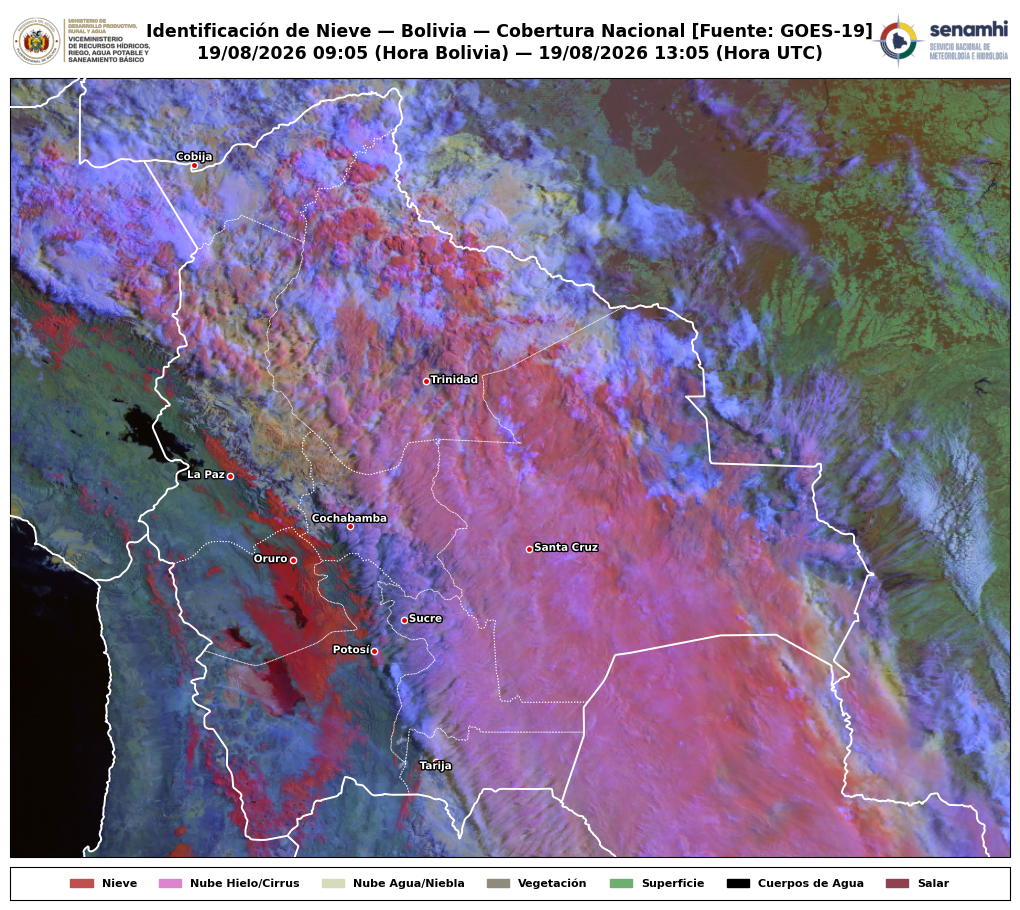

In [ ]:
import os
from datetime import datetime, timedelta
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.patheffects as patheffects
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import xarray as xr
import s3fs
import geopandas as gpd
import pandas as pd

# ==========================================
# FUNCIÓN AUXILIAR UNIFICADA: EXTENT DINÁMICO
# ==========================================
def obtener_extent_geografico(shp_path, identificador, target_aspect=1.052, buffer_pct=0.08):
    """
    Calcula el extent exacto [Oeste, Este, Sur, Norte] para encuadrar Departamentos o Macroregiones.
    Soporta IDs numéricos (OBJECTID) y nombres en texto (MacroRegio / nom_dep).
    """
    if not os.path.exists(shp_path):
        raise FileNotFoundError(f"No se encontró el archivo shapefile en: {shp_path}")

    gdf = gpd.read_file(shp_path)
    
    # Normalizar entrada a lista
    id_list = [identificador] if not isinstance(identificador, list) else identificador

    # Identificar columnas según el estándar del SHP cargado
    col_nombre = next((c for c in gdf.columns if c.lower() in ['macroregio', 'nom_dep', 'nombre']), None)
    col_codigo = next((c for c in gdf.columns if c.lower() in ['objectid', 'cod_dep', 'id', 'codigo']), None)

    # Construir máscara de filtrado
    mask = pd.Series(False, index=gdf.index)
    for elem in id_list:
        if col_codigo and (isinstance(elem, int) or str(elem).isdigit()):
            mask |= (gdf[col_codigo] == int(elem))
        elif col_nombre:
            mask |= (gdf[col_nombre].astype(str).str.contains(str(elem), case=False, na=False))

    gdf_filtrado = gdf[mask]

    if gdf_filtrado.empty:
        raise ValueError(f"No se encontraron coincidencias para '{identificador}' en {shp_path}.")

    # 1. Obtener límites geográficos combinados [minx, miny, maxx, maxy]
    minx, miny, maxx, maxy = gdf_filtrado.total_bounds
    
    # 2. Calcular centro y margen (buffer)
    cx, cy = (minx + maxx) / 2.0, (miny + maxy) / 2.0
    w = (maxx - minx) * (1.0 + buffer_pct)
    h = (maxy - miny) * (1.0 + buffer_pct)
    
    # 3. Ajustar proporciones a la relación exacta del lienzo (10 / 9.5)
    if (w / h) < target_aspect:
        w = h * target_aspect
    else:
        h = w / target_aspect
        
    return [cx - w/2.0, cx + w/2.0, cy - h/2.0, cy + h/2.0]

# ==========================================
# 1. CONFIGURACIÓN DEL USUARIO
# ==========================================
FECHA_BUSCADA = datetime(2026, 8, 19, 13, 00) 

# Seleccionar el modo de trabajo: "DEPARTAMENTO" o "MACROREGION"
MODO_REGION = "DEPARTAMENTO"

# Si MODO_REGION = "MACROREGION", puedes usar IDs (1-7), nombres ("Altiplano", "Valles") o listas ([7, 2])
# Ejemplos: 7, "Altiplano", [7, 1], ["Altiplano", "Yungas - Chapare"]
# Si MODO_REGION = "DEPARTAMENTO", usa la lógica departamental conocida (ej. "Potosi", 5, "BOLIVIA")
REGION_OBJETIVO = "BOLIVIA"

BASE_DIR = "/Users/diegoperales/Meteorology/GOES"
RAW_DATA = os.path.join(BASE_DIR, "raw_data")
OUTPUTS = os.path.join(BASE_DIR, "procesados")
os.makedirs(RAW_DATA, exist_ok=True)
os.makedirs(OUTPUTS, exist_ok=True)

# Rutas a los Shapefiles
PATH_SHP_DEPTS = os.path.join(BASE_DIR, "layers", "limites_departamentales.shp")
PATH_SHP_MACROS = os.path.join(BASE_DIR, "layers", "Macro_Regiones.shp")

# Mapeos de códigos a nombres
MAPA_DEPTS = {
    1: "CHUQUISACA", 
    2: "LA PAZ", 
    3: "COCHABAMBA", 
    4: "ORURO",
    5: "POTOSI", 
    6: "TARIJA", 
    7: "SANTA CRUZ", 
    8: "BENI", 
    9: "PANDO"
}

MAPA_MACROS = {
    1: "YUNGAS - CHAPARE",
    2: "VALLES",
    3: "LLANURAS Y SABANAS",
    4: "CHIQUITANIA",
    5: "CHACO",
    6: "AMAZONIA",
    7: "ALTIPLANO"
}

# --- CATALOGO DE LOCALIDADES REGIONALES ---
LOCALIDADES_REGIONALES = {
    # --- DEPARTAMENTOS ---
    "BOLIVIA": {
        "subtitulo": "Bolivia",
        "localidades": {
            "Cobija": {"lat": -11.02, "lon": -68.74, "pos": "top"}, 
            "Trinidad": {"lat": -14.83, "lon": -64.90, "pos": "right"},
            "La Paz": {"lat": -16.50, "lon": -68.15, "pos": "left"}, 
            "Cochabamba": {"lat": -17.38, "lon": -66.16, "pos": "top"},
            "Santa Cruz": {"lat": -17.78, "lon": -63.18, "pos": "right"}, 
            "Oruro": {"lat": -17.98, "lon": -67.11, "pos": "left"},
            "Sucre": {"lat": -19.03, "lon": -65.26, "pos": "right"}, 
            "Potosí": {"lat": -19.58, "lon": -65.75, "pos": "left"},
            "Tarija": {"lat": -21.53, "lon": -64.73, "pos": "top"}
        }
    },
    "LA PAZ": {
        "subtitulo": "La Paz",
        "localidades": {
            "El Alto": {"lat": -16.50, "lon": -68.16, "pos": "left"}, 
            "La Paz": {"lat": -16.84, "lon": -67.80, "pos": "right"},
            "Copacabana": {"lat": -16.16, "lon": -69.08, "pos": "top"}, 
            "Achacachi": {"lat": -16.04, "lon": -68.68, "pos": "right"},
            "Desaguadero": {"lat": -16.56, "lon": -69.03, "pos": "left"}, 
            "Patacamaya": {"lat": -17.23, "lon": -67.92, "pos": "right"},
            "Charaña": {"lat": -17.59, "lon": -69.44, "pos": "right"}, 
            "Caranavi": {"lat": -15.82, "lon": -67.56, "pos": "right"},
            "Apolo": {"lat": -14.72, "lon": -68.42, "pos": "top"}
        }
    },
    "ORURO": {
        "subtitulo": "Región Oruro",
        "localidades": {
            "Oruro": {"lat": -17.98, "lon": -67.11, "pos": "right"}, 
            "Huanuni": {"lat": -18.28, "lon": -66.83, "pos": "left"},
            "Orinoca": {"lat": -18.97, "lon": -67.25, "pos": "top"}, 
            "Sajama": {"lat": -18.13, "lon": -68.97, "pos": "top"},
            "Chipaya": {"lat": -19.04, "lon": -68.08, "pos": "bottom"}, 
            "Pisiga": {"lat": -19.27, "lon": -68.57, "pos": "left"},
            "Salinas de Garci-Mendoza": {"lat": -19.64, "lon": -67.62, "pos": "bottom"}
        }
    },
    "POTOSI": {
        "subtitulo": "Región Potosí",
        "localidades": {
            "Potosí": {"lat": -19.58, "lon": -65.75, "pos": "right"}, 
            "Uyuni": {"lat": -20.46, "lon": -66.82, "pos": "top"},
            "Cotagaita": {"lat": -20.55, "lon": -65.70, "pos": "right"}, 
            "Tupiza": {"lat": -21.44, "lon": -65.72, "pos": "bottom"},
            "Villazón": {"lat": -22.09, "lon": -65.59, "pos": "top"}, 
            "San Pablo de Lípez": {"lat": -21.72, "lon": -66.62, "pos": "top"},
            "Colcha K": {"lat": -20.76, "lon": -67.65, "pos": "bottom"}, 
            "Laguna Colorada": {"lat": -22.17, "lon": -67.81, "pos": "left"}
        }
    },
    "COCHABAMBA": {
        "subtitulo": "Región Cochabamba",
        "localidades": {
            "Cochabamba": {"lat": -17.38, "lon": -66.16, "pos": "bottom"}, 
            "Misicuni": {"lat": -17.18, "lon": -66.32, "pos": "left"},
            "Confital": {"lat": -17.60, "lon": -66.86, "pos": "left"}, 
            "Toralapa": {"lat": -17.35, "lon": -65.45, "pos": "bottom"},
            "Anzaldo": {"lat": -17.76, "lon": -65.71, "pos": "bottom"}, 
            "Mizque": {"lat": -18.14, "lon": -65.10, "pos": "bottom"},
            "Villa Tunari": {"lat": -16.97, "lon": -65.42, "pos": "right"}
        }
    },

    # --- MACROREGIONES ---
    "ALTIPLANO": {
        "subtitulo": "Región Altiplano",
        "localidades": {
            "El Alto": {"lat": -16.50, "lon": -68.16, "pos": "left"},
            "Achacachi": {"lat": -16.04, "lon": -68.68, "pos": "right"},
            "Desaguadero": {"lat": -16.56, "lon": -69.03, "pos": "left"}, 
            "Patacamaya": {"lat": -17.23, "lon": -67.92, "pos": "right"},
            "Charaña": {"lat": -17.59, "lon": -69.44, "pos": "right"},  
            "Oruro": {"lat": -17.98, "lon": -67.11, "pos": "right"},
            "Uyuni": {"lat": -20.46, "lon": -66.82, "pos": "top"}, 
            "Copacabana": {"lat": -16.16, "lon": -69.08, "pos": "top"},
            "Sajama": {"lat": -18.13, "lon": -68.97, "pos": "top"}, 
            "Villazón": {"lat": -22.09, "lon": -65.59, "pos": "top"}
        }
    },
    "YUNGAS - CHAPARE": {
        "subtitulo": "Región Yungas - Chapare",
        "localidades": {
            "Caranavi": {"lat": -15.82, "lon": -67.56, "pos": "right"}, 
            "Chulumani": {"lat": -16.40, "lon": -67.52, "pos": "right"},
            "Villa Tunari": {"lat": -16.97, "lon": -65.42, "pos": "right"}, 
            "Coroico": {"lat": -16.18, "lon": -67.72, "pos": "left"}
        }
    },
    "VALLES": {
        "subtitulo": "Región Valles",
        "localidades": {
            "Cochabamba": {"lat": -17.38, "lon": -66.16, "pos": "bottom"}, 
            "Sucre": {"lat": -19.03, "lon": -65.26, "pos": "right"},
            "Tarija": {"lat": -21.53, "lon": -64.73, "pos": "bottom"}, 
            "Potosí": {"lat": -19.58, "lon": -65.75, "pos": "left"}
        }
    },
    "CHACO": {
        "subtitulo": "Región Chaco",
        "localidades": {
            "Yacuiba": {"lat": -22.01, "lon": -63.68, "pos": "left"}, 
            "Villamontes": {"lat": -21.26, "lon": -63.47, "pos": "right"},
            "Camiri": {"lat": -20.03, "lon": -63.52, "pos": "right"}
        }
    },
    "AMAZONIA": {
        "subtitulo": "Región Amazonía",
        "localidades": {
            "Cobija": {"lat": -11.02, "lon": -68.74, "pos": "top"}, 
            "Riberalta": {"lat": -11.00, "lon": -66.06, "pos": "right"},
            "Guayaramerín": {"lat": -10.83, "lon": -65.36, "pos": "right"}
        }
    },
    "LLANURAS Y SABANAS": {
        "subtitulo": "Región Llanuras y Sabanas",
        "localidades": {
            "Trinidad": {"lat": -14.83, "lon": -64.90, "pos": "right"}, 
            "San Borja": {"lat": -14.85, "lon": -66.75, "pos": "left"},
            "Santa Ana de Yacuma": {"lat": -13.75, "lon": -65.43, "pos": "top"}
        }
    },
    "CHIQUITANIA": {
        "subtitulo": "Región Chiquitania",
        "localidades": {
            "San Ignacio de Velasco": {"lat": -16.37, "lon": -60.95, "pos": "top"}, 
            "San José de Chiquitos": {"lat": -17.85, "lon": -60.75, "pos": "bottom"},
            "Puerto Suárez": {"lat": -18.96, "lon": -57.80, "pos": "left"}
        }
    }
}

# --- SELECCIÓN DINÁMICA DEL SHAPEFILE Y METADATOS ---
es_macro = (MODO_REGION.upper() == "MACROREGION")
shp_activo = PATH_SHP_MACROS if es_macro else PATH_SHP_DEPTS
mapa_codigos_activo = MAPA_MACROS if es_macro else MAPA_DEPTS

if isinstance(REGION_OBJETIVO, str) and REGION_OBJETIVO.upper() == "BOLIVIA":
    extent_final = [-71.8, -55.2, -23.2, -9.5]
    subtitulo_final = LOCALIDADES_REGIONALES["BOLIVIA"]["subtitulo"]
    localidades_final = LOCALIDADES_REGIONALES["BOLIVIA"]["localidades"]
else:
    # Extent calculado desde el SHP correspondiente
    extent_final = obtener_extent_geografico(shp_activo, REGION_OBJETIVO)
    
    # Construcción de subtítulos y consolidación de localidades
    if isinstance(REGION_OBJETIVO, list):
        nombres_reg = []
        localidades_final = {}
        for item in REGION_OBJETIVO:
            key = mapa_codigos_activo.get(item, str(item)).upper()
            nombres_reg.append(key.title())
            if key in LOCALIDADES_REGIONALES:
                localidades_final.update(LOCALIDADES_REGIONALES[key]["localidades"])
        
        prefix = "Macroregión" if es_macro else "Departamento"
        subtitulo_final = f"{prefix} { ' - '.join(nombres_reg) }"
    else:
        key_reg = mapa_codigos_activo.get(REGION_OBJETIVO, str(REGION_OBJETIVO)).upper()
        info_reg = LOCALIDADES_REGIONALES.get(key_reg, {})
        subtitulo_final = info_reg.get("subtitulo", f"{'Macroregión' if es_macro else 'Departamento'} {key_reg.title()}")
        localidades_final = info_reg.get("localidades", {})

# ==========================================
# 2. CONEXIÓN A AMAZON S3
# ==========================================
print(f"Conectando a la NOAA para descargar el producto Snow/Fog RGB ({FECHA_BUSCADA} UTC)...")
fs = s3fs.S3FileSystem(anon=True)

doy = FECHA_BUSCADA.strftime('%j') 
anio = FECHA_BUSCADA.strftime('%Y')
hora = FECHA_BUSCADA.strftime('%H')

s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora}/"

try:
    archivos = fs.ls(s3_folder)
    archivos_multi = [f for f in archivos if f.endswith('.nc')]
    
    if not archivos_multi:
        print(f"Alerta: No hay datos en la hora {hora}. Intentando buscar un bloque antes...")
        hora_alterna = f"{int(hora)-1:02d}"
        s3_folder = f"noaa-goes19/ABI-L2-MCMIPF/{anio}/{doy}/{hora_alterna}/"
        archivos = fs.ls(s3_folder)
        archivos_multi = [f for f in archivos if f.endswith('.nc')]
        
    s3_path = archivos_multi[0]
    file_name = s3_path.split('/')[-1]
    local_path = os.path.join(RAW_DATA, file_name)
    
    if not os.path.exists(local_path):
        print(f"Descargando archivo multibanda: {file_name}...")
        fs.get(s3_path, local_path)
    else:
        print("Cargando desde disco...")
        
    ds = xr.open_dataset(local_path)

except Exception as e:
    print(f"Error crítico: {e}")
    raise e

# ==========================================
# 3. PROYECCIÓN SATELITAL
# ==========================================
glob_attrs = ds.goes_imager_projection.attrs
height = glob_attrs['perspective_point_height']
lon_0 = glob_attrs['longitude_of_projection_origin']
sweep = glob_attrs['sweep_angle_axis']

dataprojenv = ccrs.Geostationary(central_longitude=lon_0, satellite_height=height, sweep_axis=sweep)

# ==========================================
# 4. COMPOSICIÓN SNOW/ICE
# ==========================================
print("Calibrando componentes físicos del producto Snow/Fog RGB...")

ch03_raw = ds['CMI_C03'].data.astype(float)  # 0.86 µm
ch05_raw = ds['CMI_C05'].data.astype(float)  # 1.60 µm
ch07_raw = ds['CMI_C07'].data.astype(float)  # 3.90 µm
ch13_raw = ds['CMI_C13'].data.astype(float)  # 10.30 µm

ch03_pct = ch03_raw if np.max(ch03_raw) > 1.0 else ch03_raw * 100.0
ch05_pct = ch05_raw if np.max(ch05_raw) > 1.0 else ch05_raw * 100.0

# Rojo (Canal 3)
R_min, R_max = 0.0, 100.0
R = (ch03_pct - R_min) / (R_max - R_min)
R = np.clip(R, 0, 1)
R = np.power(R, 1.0 / 1.7)

# Verde (Canal 5)
G_min, G_max = 0.0, 70.0
G = (ch05_pct - G_min) / (G_max - G_min)
G = np.clip(G, 0, 1)
G = np.power(G, 1.0 / 1.7)

# Azul (Ch07 - Ch13)
blue_diff = ch07_raw - ch13_raw
B_min, B_max = 0.0, 30.0
B = (blue_diff - B_min) / (B_max - B_min)
B = np.clip(B, 0, 1)
B = np.power(B, 1.0 / 1.7)

rgb_image = np.dstack((R, G, B))

# ==========================================
# 5. GENERACIÓN DEL PRODUCTO VISUAL
# ==========================================
# Configuración del lienzo
fig, ax = plt.subplots(figsize=(10, 9.5), facecolor='white', subplot_kw={'projection': ccrs.PlateCarree()})

# Ajuste de márgenes externos
fig.subplots_adjust(left=0.00, right=1.00, top=0.88, bottom=0.06)

# --- AJUSTE GEOGRÁFICO EQUILIBRADO SEGÚN EL DEPARTAMENTO O REGIÓN ---
ax.set_extent(extent_final, crs=ccrs.PlateCarree())

# --- EFECTO BORDERLESS ---
X_grid = ds.x.data * height
Y_grid = ds.y.data * height

# imshow con aspect='auto' es más rápido y exacto
x_min, x_max = X_grid.min(), X_grid.max()
y_min, y_max = Y_grid.min(), Y_grid.max()

# Eestirar la imagen satelital para rellenar los bordes laterales vacíos
ax.imshow(rgb_image, origin='upper', transform=dataprojenv, 
          extent=[x_min, x_max, y_min, y_max], aspect='auto', zorder=1)

import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature

# --- CAPA 1: LÍMITES GEOGRÁFICOS POLÍTICO-ADMINISTRATIVOS ---
COLOR_BLANCO = '#ffffff'

# 1. Costas y Fronteras de países (Resolución 10m de Cartopy)
# Declaramos explícitamente la resolución '10m' para que coincida exactamente con los estados
borde_nacional = cfeature.NaturalEarthFeature(category='cultural',
                                              name='admin_0_boundary_lines_land',
                                              scale='10m',
                                              facecolor='none')

costas = cfeature.NaturalEarthFeature(category='physical',
                                      name='coastline',
                                      scale='10m',
                                      facecolor='none')

ax.add_feature(costas, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)
ax.add_feature(borde_nacional, linestyle='-', edgecolor=COLOR_BLANCO, linewidth=1.4, zorder=3)


# 2. Límites Subnacionales (Departamentos de Bolivia)
# Extraemos los estados de la base de datos de Cartopy a la misma resolución '10m'
shapename = shpreader.natural_earth(resolution='10m', category='cultural', name='admin_1_states_provinces')
reader = shpreader.Reader(shapename)

# Filtramos la base de datos global para obtener SOLO los de Bolivia
bolivia_states = [estado.geometry for estado in reader.records() if estado.attributes['admin'] == 'Bolivia']

# Dibujamos los departamentos
ax.add_geometries(bolivia_states, crs=ccrs.PlateCarree(), 
                  facecolor='none', edgecolor=COLOR_BLANCO, 
                  linestyle=(0, (1, 2)), linewidth=0.7, zorder=4)

# --- CAPA 2: LOCALIDADES POR DEPARTAMENTO O REGIÓN ---

# El bucle ahora lee el diccionario de la región activa:
for ciudad, info in localidades_final.items():
    ax.plot(info["lon"], info["lat"], marker='o', color='#E50001', markersize=4.5, 
            markeredgecolor='white', markeredgewidth=1.0, transform=ccrs.PlateCarree(), zorder=10)
    
    offset_lon = 0.08 if info["pos"] == "right" else (-0.08 if info["pos"] == "left" else 0)
    offset_lat = 0.08 if info["pos"] == "top" else (-0.12 if info["pos"] == "bottom" else -0.03)
    alignment_h = "left" if info["pos"] == "right" else ("right" if info["pos"] == "left" else "center")
    
    ax.text(info["lon"] + offset_lon, info["lat"] + offset_lat, ciudad, color='white', 
            fontsize=7.5, fontweight='bold', horizontalalignment=alignment_h, 
            transform=ccrs.PlateCarree(), zorder=11, 
            path_effects=[patheffects.withStroke(linewidth=2, foreground='black')])

# --- CAPA 3: PROCESAMIENTO DE FECHAS ---
fecha_utc = datetime.strptime(ds.t.dt.strftime('%Y-%m-%d %H:%M').item(), '%Y-%m-%d %H:%M')
fecha_bot = fecha_utc - timedelta(hours=4)
string_utc = fecha_utc.strftime('%d/%m/%Y %H:%M (Hora UTC)')
string_bot = fecha_bot.strftime('%d/%m/%Y %H:%M (Hora Bolivia)')

# --- CAPA 4: TÍTULO CORPORATIVO ADAPTADO DINÁMICO ---
ax.set_title(
    f"Identificación de Nieve — {subtitulo_final} [Fuente: GOES-19]\n"
    f"{string_bot} — {string_utc}", 
    fontsize=12.5, fontweight='bold', pad=14, loc='center', linespacing=1.3
)

# --- CAPA 5: LEYENDA HORIZONTAL ---
pos_mapa = ax.get_position()
ax_leyenda = fig.add_axes([0.00, pos_mapa.y0 - 0.045, 1.00, 0.035]) # Forzamos ancho completo 0.00 a 1.00
ax_leyenda.set_facecolor('#ffffff')
ax_leyenda.set_xticks([])
ax_leyenda.set_yticks([])

parches_leyenda = [
    mpatches.Patch(color='#BE5050', label='Nieve'), 
    mpatches.Patch(color='#DD84CE', label='Nube Hielo/Cirrus'),
    mpatches.Patch(color='#D6DCBB', label='Nube Agua/Niebla'),
    mpatches.Patch(color='#8F8A7A', label='Vegetación'),
    mpatches.Patch(color='#6EAE70', label='Superficie'),
    mpatches.Patch(color='#000000', label='Cuerpos de Agua'),
    mpatches.Patch(color='#8E4151', label='Salar')
]

leyenda = ax_leyenda.legend(handles=parches_leyenda, loc='center', ncol=7, frameon=False, fontsize=8.0)

for text in leyenda.get_texts():
    text.set_color('black')
    text.set_weight('bold')

# --- CAPA 6: INSERCIÓN DE LOGOS ---
PATH_LOGOS = os.path.join(BASE_DIR, "logos")
try:
    img_ministerio_path = os.path.join(PATH_LOGOS, "logo_ministerio.png")
    img_senamhi_path = os.path.join(PATH_LOGOS, "logo_senamhi.png")
    
    if os.path.exists(img_ministerio_path) and os.path.exists(img_senamhi_path):
        logo_ministerio = mpimg.imread(img_ministerio_path)
        logo_senamhi = mpimg.imread(img_senamhi_path)
        
        ax_logo_min = fig.add_axes([pos_mapa.x0, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_min.imshow(logo_ministerio)
        ax_logo_min.axis('off')
        
        ax_logo_sen = fig.add_axes([pos_mapa.x1 - 0.14, pos_mapa.y1 + 0.005, 0.14, 0.07]) 
        ax_logo_sen.imshow(logo_senamhi)
        ax_logo_sen.axis('off')
        print("Carimbo y logos adaptados correctamente.")
except Exception as e:
    print(f"Alerta logos: {e}")

# --- GUARDAR ARCHIVO CON NOMBRE DINÁMICO ---
if isinstance(REGION_OBJETIVO, list):
    str_region = "_".join([str(x) for x in REGION_OBJETIVO])
else:
    str_region = str(REGION_OBJETIVO)

output_name = f"{OUTPUTS}/GOES19_DaySnowFog_SENAMHI_{MODO_REGION.upper()}_{str_region.upper()}_{fecha_utc.strftime('%Y%m%d_%H%M')}.png"

plt.savefig(output_name, dpi=200, bbox_inches='tight', pad_inches=0.03)
print(f"¡Producto Snow/Fog RGB generado con éxito!: {output_name}")

plt.show()